# Finalize Gene Clusters (manual merge variant)

**Human-judgment path, now also Snakemake-buildable.** This notebook produces ONE `manual_merge` finalize variant. The other variants (`direct` / `auto_merge` / `grid`) are fully automatic. This one keeps a hand-tuned `merge_groups` dict (the human judgment), but the notebook itself is run — either interactively (open it in Jupyter, eyeball the plots, adjust `merge_groups`) OR headlessly by the `finalize_manual_merge` rule, which executes it via Snakemake's native `notebook:` directive (`jupyter-nbconvert --execute`) and captures the executed copy under `logs/clustering/`.

## Dual execution mode
- **Under Snakemake** the injected `snakemake` object supplies dataset / variant / params / input & output paths, and the cwd is the repo root.
- **Interactively** (opened from `notebooks/clustering/`) it falls back to the defaults in the config cell and resolves the repo root from the cwd.

## Inputs (from the prepare spine)
- `results/clustering/{dataset}/_work/annotated_data.parquet`  (annotated fitting table)
- `results/clustering/{dataset}/_work/scaled_data.parquet`  (scaled DR/DL matrix)

The notebook clusters the scaled matrix to `N_INTERMEDIATE` with `METHOD` itself (same call the buildable variants use — there is no shared candidate stage), so it works for any method.

## Outputs
- `results/clustering/{dataset}/{variant}/final_clusters.tsv`  (full annotated table + unified `cluster` column 1..9 with WT=9, plus a `raw_cluster` column holding the `N_INTERMEDIATE` pre-merge labels — same contract as the buildable variants; consumed by enrichment.smk + ml.smk when this variant is selected).
- `results/clustering/{dataset}/{variant}/metrics.tsv`  (silhouette / Calinski-Harabasz / Davies-Bouldin on the final labels, so this variant appears in `compare_variants`).

**The `merge_groups` dict is the human judgment.** You maintain ONE dict mapping each raw transitional id (0..N_INTERMEDIATE-1) to a merge-group label. Final numbering is then computed automatically by the shared `renumber_by_dr` (lowest mean DR = WT) — you no longer hand-assign final ids. When running headlessly, the dict currently committed here is what gets used, so review it against the plot below before relying on a pipeline build.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Resolve the repo root for both execution modes, then make workflow.src importable:
# - Under Snakemake's `notebook:` directive the injected preamble chdir's to the
#   workdir (repo root) and defines `snakemake`; Path.cwd() is already the repo root.
# - Interactively (opened from notebooks/clustering/) fall back to two levels up.
try:
    snakemake  # noqa: F821  (injected by Snakemake's notebook: directive)
    REPO = Path.cwd()
except NameError:
    REPO = Path.cwd().parents[1]
sys.path.insert(0, str(REPO))

from workflow.src.clustering.candidates import cluster_one_method, renumber_by_dr, score_labels
from workflow.src.io import read_parquet
from workflow.src.plotting.gene_level import visualize_cluster_on_feature_space

In [2]:
# --- Config: resolve params / paths (Snakemake object if present, else interactive defaults) ---
try:
    snakemake  # noqa: F821
    _SM = True
except NameError:
    _SM = False

if _SM:
    # Headless: everything comes from the finalize_manual_merge rule.
    DATASET = snakemake.wildcards["dataset"]
    VARIANT = snakemake.wildcards["variant"]
    METHOD = snakemake.params["method"]
    N_INTERMEDIATE = int(snakemake.params["n_intermediate"])
    WT_CLUSTER = int(snakemake.params["wt_cluster"])
    FINAL_N_CLUSTERS = int(snakemake.params["final_n_clusters"])
    RANDOM_STATE = int(snakemake.params["random_state"])
    ANNOTATED_PATH = Path(snakemake.input["annotated"])
    SCALED_PATH = Path(snakemake.input["scaled"])
    OUTPUT = Path(snakemake.output["clusters"])
    METRICS_OUTPUT = Path(snakemake.output["metrics"])
else:
    # Interactive defaults — switch DATASET/METHOD/VARIANT to your target.
    DATASET = "HD_DIT_HAP"
    METHOD = "kmeans"                       # clustering method for the transitional labels
    N_INTERMEDIATE = 64                     # transitional cluster count (match the variant's config)
    VARIANT = "kmeans_merge9_manual"        # must match a manual_merge variant in analysis.yaml
    WT_CLUSTER = 9                          # final id for the lowest-DR (WT) group
    FINAL_N_CLUSTERS = 9
    RANDOM_STATE = 42
    WORK = REPO / f"results/clustering/{DATASET}/_work"
    ANNOTATED_PATH = WORK / "annotated_data.parquet"
    SCALED_PATH = WORK / "scaled_data.parquet"
    OUTPUT = REPO / f"results/clustering/{DATASET}/{VARIANT}/final_clusters.tsv"
    METRICS_OUTPUT = REPO / f"results/clustering/{DATASET}/{VARIANT}/metrics.tsv"

# Read the annotated table + scaled matrix from the spine, then cluster the scaled
# matrix to N_INTERMEDIATE transitional clusters ourselves (same call the buildable
# variants use — there is no shared candidate stage).
annotated = read_parquet(ANNOTATED_PATH)
scaled = read_parquet(SCALED_PATH)
raw_labels = pd.Series(
    cluster_one_method(METHOD, scaled, N_INTERMEDIATE, RANDOM_STATE), index=scaled.index
)
data_df = annotated.copy()
data_df["raw_cluster"] = raw_labels
data_df.shape, sorted(raw_labels.unique())[:10]

2026-07-22 20:08:58.075 | INFO     | workflow.src.clustering.candidates:cluster_one_method:150 - Running K-means clustering


((4513, 20),
 [np.int32(0),
  np.int32(1),
  np.int32(2),
  np.int32(3),
  np.int32(4),
  np.int32(5),
  np.int32(6),
  np.int32(7),
  np.int32(8),
  np.int32(9)])

## 1. Review the transitional clusters

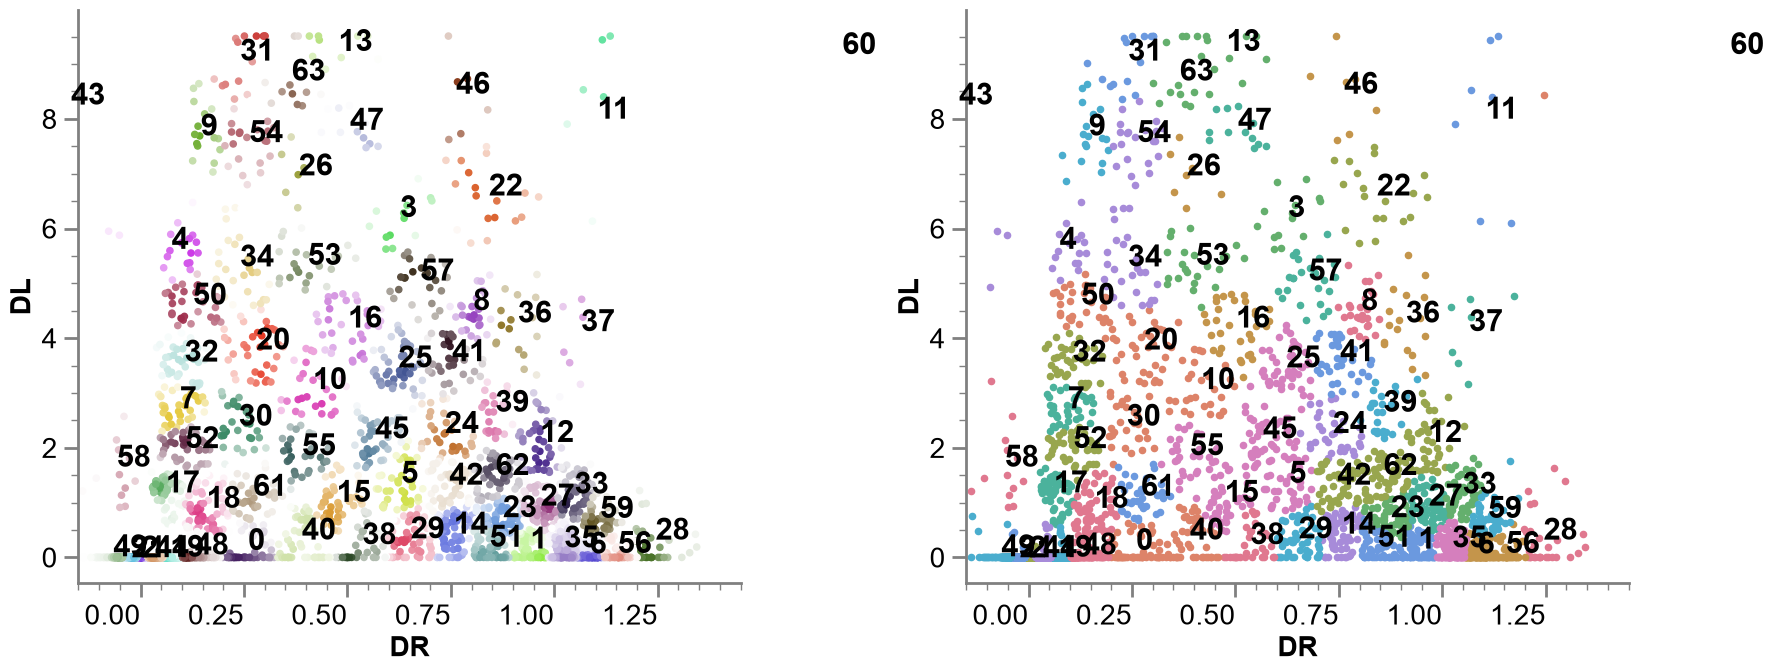

In [3]:
# Only genes that were actually clustered have a raw_cluster (others are NaN).
clustered = data_df.dropna(subset=["raw_cluster"]).copy()
clustered["raw_cluster"] = clustered["raw_cluster"].astype(int)
fig = visualize_cluster_on_feature_space(clustered, 'raw_cluster')
plt.show()

## 2. Merge transitional clusters → groups (single dict), then auto-number by DR

Maintain the ONE dict below: raw transitional id (0..N_INTERMEDIATE-1) → an arbitrary merge-group label. Group labels can be any integers — they only define *which transitional clusters merge together*. Final ids are then assigned automatically by mean DR (`renumber_by_dr`), so you never hand-number.

The dict below is the HD kmeans starting point (N_INTERMEDIATE=64). **Adjust by eye** against the plot above for the current dataset/method — cluster geometry differs, so this mapping is unlikely to be correct elsewhere. Every raw id present in the data must appear as a key, and the number of distinct group labels must equal `FINAL_N_CLUSTERS`.

In [4]:
# raw transitional id (0..N_INTERMEDIATE-1) -> arbitrary merge-group label (HD kmeans, N_INTERMEDIATE=64).
merge_groups = {0: 7,
 1: 2,
 2: 9,
 3: 6,
 4: 9,
 5: 5,
 6: 1,
 7: 9,
 8: 6,
 9: 9,
 10: 8,
 11: 6,
 12: 4,
 13: 6,
 14: 3,
 15: 7,
 16: 8,
 17: 9,
 18: 9,
 19: 9,
 20: 8,
 21: 9,
 22: 6,
 23: 2,
 24: 5,
 25: 6,
 26: 9,
 27: 2,
 28: 1,
 29: 3,
 30: 8,
 31: 9,
 32: 9,
 33: 1,
 34: 8,
 35: 1,
 36: 6,
 37: 6,
 38: 3,
 39: 4,
 40: 7,
 41: 6,
 42: 5,
 43: 9,
 44: 9,
 45: 5,
 46: 6,
 47: 6,
 48: 9,
 49: 9,
 50: 9,
 51: 2,
 52: 9,
 53: 8,
 54: 9,
 55: 7,
 56: 1,
 57: 6,
 58: 9,
 59: 1,
 60: 6,
 61: 7,
 62: 4,
 63: 9}

# Map each clustered gene to its merge group, then auto-number by mean DR (WT = lowest).
group_labels = clustered["raw_cluster"].map(merge_groups)
assert group_labels.notna().all(), "every raw id in the data must be a key in merge_groups"
assert group_labels.nunique() == FINAL_N_CLUSTERS, (
    f"merge_groups has {group_labels.nunique()} distinct groups, expected {FINAL_N_CLUSTERS}"
)
final = renumber_by_dr(clustered, group_labels, n_clusters=FINAL_N_CLUSTERS, wt_cluster=WT_CLUSTER)

# Write final labels back onto the full annotated frame (unclustered genes stay NaN).
data_df["cluster"] = final.reindex(data_df.index)
data_df.loc[clustered.index, "cluster"].value_counts().sort_index()

cluster
1     424
2     242
3     110
4     228
5     155
6     139
7     205
8     174
9    2836
Name: count, dtype: int64

## 3. Review the merged 1..9 clusters (WT = 9)

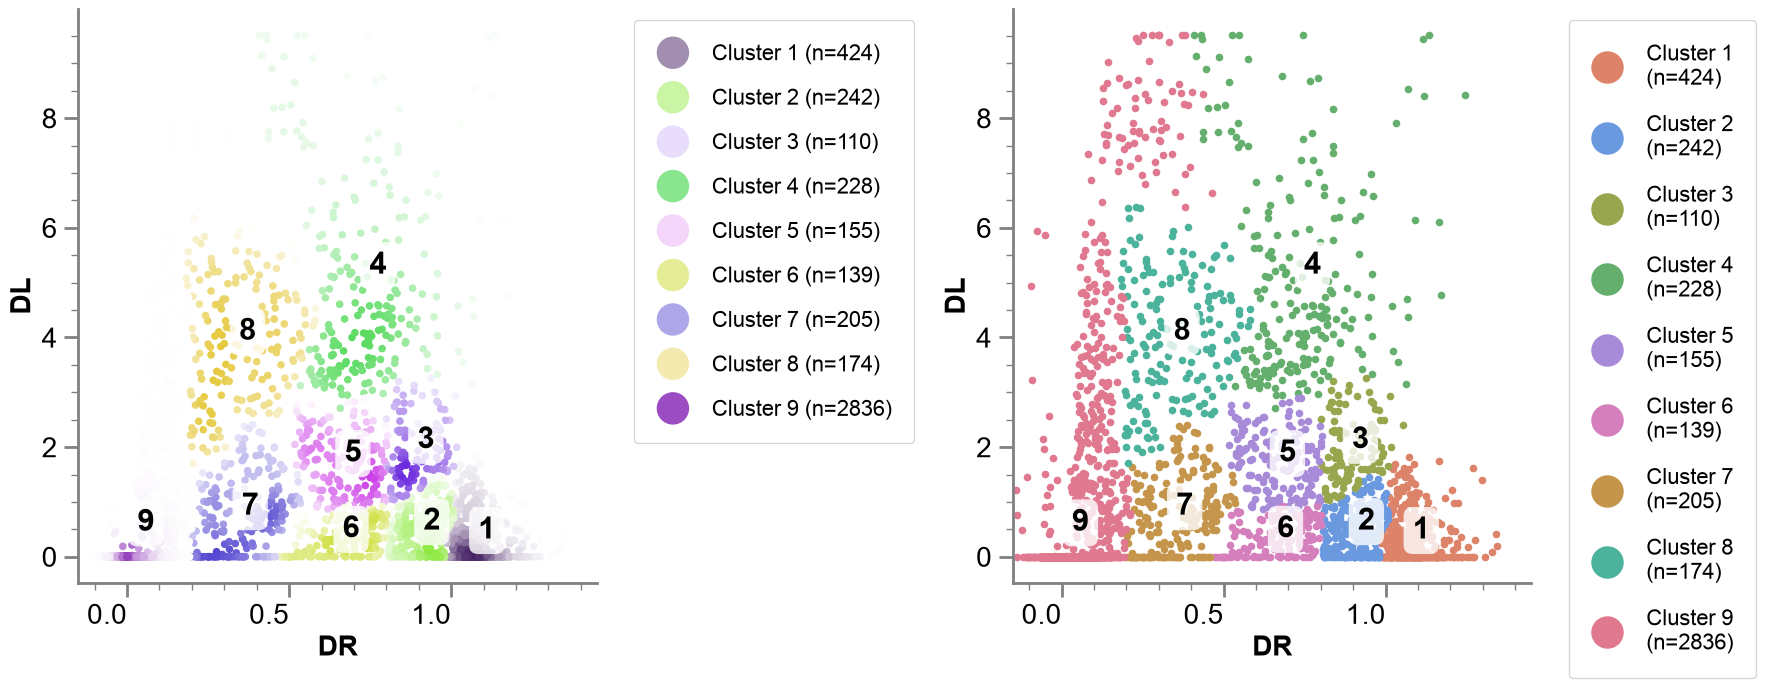

In [5]:
plot_df = data_df.dropna(subset=["cluster"]).copy()
plot_df["cluster"] = plot_df["cluster"].astype(int)
fig = visualize_cluster_on_feature_space(
    plot_df, 'cluster', show_box=True, legend=True, cluster_minus_one=True
)
plt.show()

## 4. Write the artifacts (final_clusters.tsv + metrics.tsv)

Interactively, run this once you are satisfied with the merge above. Headlessly, the `finalize_manual_merge` rule runs the whole notebook and this cell writes the outputs. Both go to `results/clustering/{dataset}/{variant}/` and are consumed by enrichment + ml.

In [6]:
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
data_df.to_csv(OUTPUT, sep="\t", index=True)
print(f"Wrote {len(data_df)} genes ({data_df['cluster'].notna().sum()} clustered) to {OUTPUT}")

# Per-variant metrics on the final clustering (label-permutation-invariant scores) so
# this variant shows up in compare_variants alongside the buildable ones.
final = data_df.loc[scaled.index, "cluster"]
metrics = pd.DataFrame([{"variant_type": "manual_merge", **score_labels(scaled, final.to_numpy())}])
METRICS_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
metrics.to_csv(METRICS_OUTPUT, sep="\t", index=False)
print(f"Wrote metrics to {METRICS_OUTPUT}")

Wrote 4513 genes (4513 clustered) to /data/c/yangyusheng_optimized/DIT_HAP_analysis/results/clustering/HD_DIT_HAP/kmeans_merge9_manual/final_clusters.tsv
